# Lab 3: Facebook Prophet — Forecasting the Daily Delhi Climate Dataset (Student Version)

## Objective
Apply Prophet's decomposable forecasting framework to the Daily Climate Delhi Dataset:
1. Environment setup and data ingestion.
2. Exploratory Data Analysis and schema preparation.
3. Model trials: baseline, trend, seasonality, and regressors.
4. Visualization: forecast components and changepoints.
5. Cross-validation and performance metrics.
6. Forecasting with prediction intervals.

### Task 1: Import Necessary Libraries
Import Prophet alongside the standard data science stack and Prophet's diagnostic utilities.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# TODO 1: Import the following from prophet:
# - Prophet (from prophet)
# - plot_forecast_component (from prophet.plot)
# - cross_validation, performance_metrics (from prophet.diagnostics)

# Your imports here:
from prophet import Prophet
from prophet.plot import plot_forecast_component
from prophet.diagnostics import cross_validation, performance_metrics

### Task 2: Load and Inspect the Dataset
We use the `sumanthvrao/daily-climate-time-series-data` dataset. The target column is `meantemp`.

In [7]:
# TODO 2.1: Load 'DailyDelhiClimateTrain.csv' into a DataFrame.
df = pd.read_csv("DailyDelhiClimateTrain.csv")

# TODO 2.2: Print shape, dtypes, and first 5 rows.
print(f"shape of data: {df.shape}")
print(f"dtypes of data: {df.dtypes}")
print(df.head())
# TODO 2.3: Check for missing values in meantemp and report the count.
print(f"missing values in meantemp: {df['meantemp'].isnull().sum()}")

shape of data: (1462, 5)
dtypes of data: date             object
meantemp        float64
humidity        float64
wind_speed      float64
meanpressure    float64
dtype: object
         date   meantemp   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000
missing values in meantemp: 0


### Task 3: Schema Mapping — Prepare the Prophet-Compatible DataFrame
Prophet requires exactly two columns: `ds` (datestamp) and `y` (target). Rename and cast accordingly.

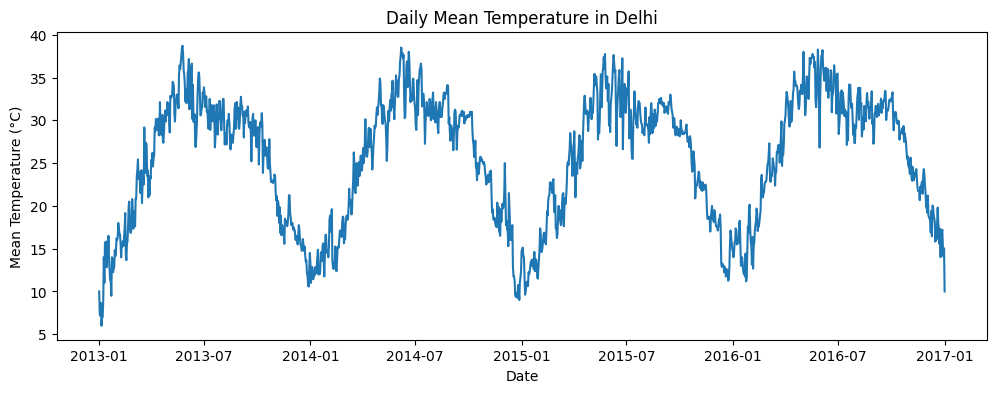

In [9]:
# TODO 3.1: Rename 'date' -> 'ds' and 'meantemp' -> 'y'.
df = df.rename(columns={"date": "ds", "meantemp": "y"})
# TODO 3.2: Convert 'ds' to datetime using pd.to_datetime().
df["ds"] = pd.to_datetime(df["ds"])

# TODO 3.3: Sort by 'ds' and reset the index.
prophet_df = df.sort_values("ds").reset_index(drop=True)

# TODO 3.4: Plot the raw y series using matplotlib to inspect trend and seasonality.
# Use fig, ax = plt.subplots(figsize=(12, 4)).
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(prophet_df["ds"], prophet_df["y"])
ax.set_title("Daily Mean Temperature in Delhi")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Temperature (°C)")
plt.show()

* data is not stationary i normaly transform it till it become stationary but because we are using prophet model i dont have to it can handle non stationary model

### Task 4: Model Trial 1 — Baseline Prophet (Default Settings)
Fit Prophet with all default parameters. This is your baseline before any tuning.

In [24]:
# TODO 4.1: Instantiate Prophet() with default parameters and fit on prophet_df.

pro_df = prophet_df[["ds", "y"]].dropna()
m1 = Prophet()
m1.fit(pro_df)
# TODO 4.2: Create a future DataFrame for 365 days using make_future_dataframe().
future1 = m1.make_future_dataframe(periods=365)

# TODO 4.3: Generate forecast using model.predict().
forecast1 = m1.predict(future1)

# TODO 4.4: Display the last 5 rows of ['ds', 'yhat', 'yhat_lower', 'yhat_upper'].
cols = ["ds", "yhat", "yhat_lower", "yhat_upper"]
print(forecast1[cols].tail())

16:37:38 - cmdstanpy - INFO - Chain [1] start processing
16:37:38 - cmdstanpy - INFO - Chain [1] done processing


             ds       yhat  yhat_lower  yhat_upper
1822 2017-12-28  15.787673   12.980573   18.320441
1823 2017-12-29  15.691118   12.894420   18.352802
1824 2017-12-30  15.559343   12.702007   18.464735
1825 2017-12-31  15.418906   12.925408   18.119472
1826 2018-01-01  15.607802   12.982861   18.317173


### Task 5: Visualizing the Baseline Forecast
Use Prophet's built-in matplotlib plot functions to inspect the forecast and its components.

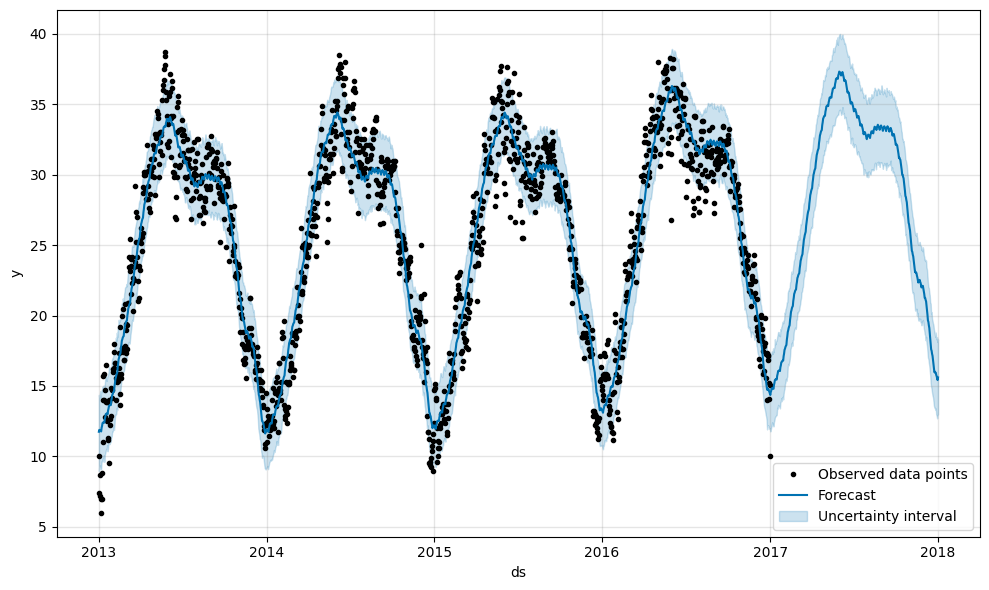

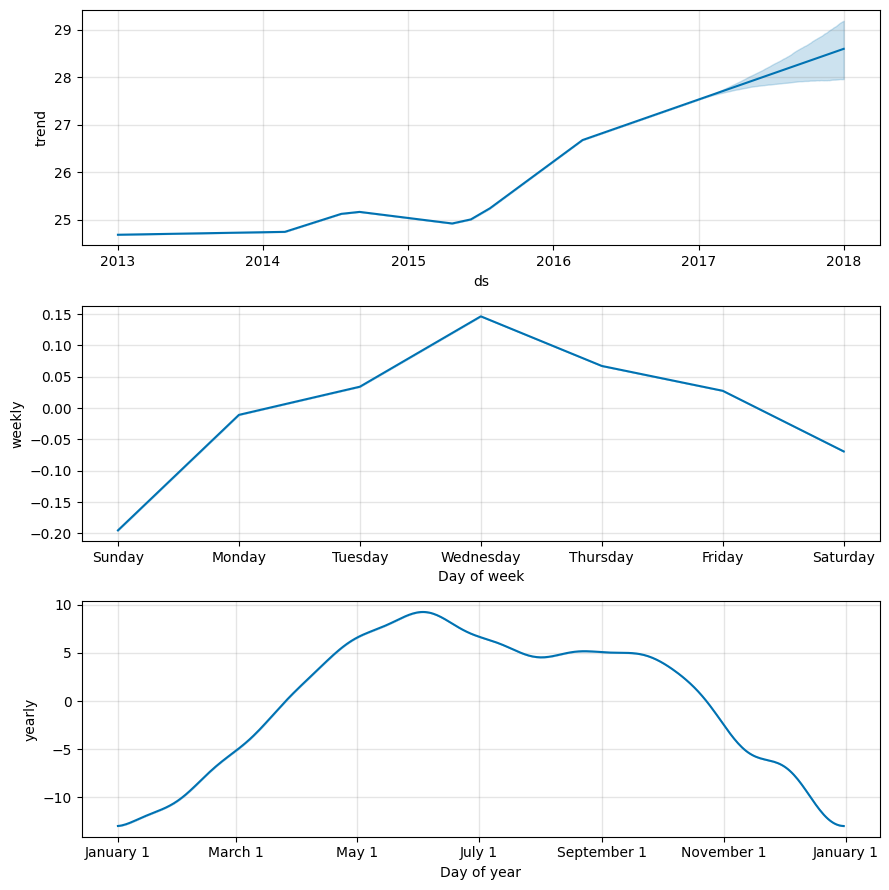

In [26]:
# TODO 5.1: Plot the full forecast using m1.plot(forecast1).
# Add a title and axis labels via the returned axes object.
m1.plot(forecast1, include_legend=True)
# TODO 5.2: Plot the decomposed components using m1.plot_components(forecast1).
# Observe: trend, weekly seasonality, yearly seasonality.
fig = m1.plot_components(forecast1)
plt.tight_layout()
plt.show()


### Task 6: Model Trial 2 — Tuning Growth and Changepoints
Explore how `changepoint_prior_scale` affects trend flexibility.

19:00:45 - cmdstanpy - INFO - Chain [1] start processing
19:00:45 - cmdstanpy - INFO - Chain [1] done processing
19:00:45 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
19:00:45 - cmdstanpy - INFO - Chain [1] start processing
19:00:47 - cmdstanpy - INFO - Chain [1] done processing
19:00:47 - cmdstanpy - INFO - Chain [1] start processing
19:00:47 - cmdstanpy - INFO - Chain [1] done processing
19:00:48 - cmdstanpy - INFO - Chain [1] start processing
19:00:48 - cmdstanpy - INFO - Chain [1] done processing


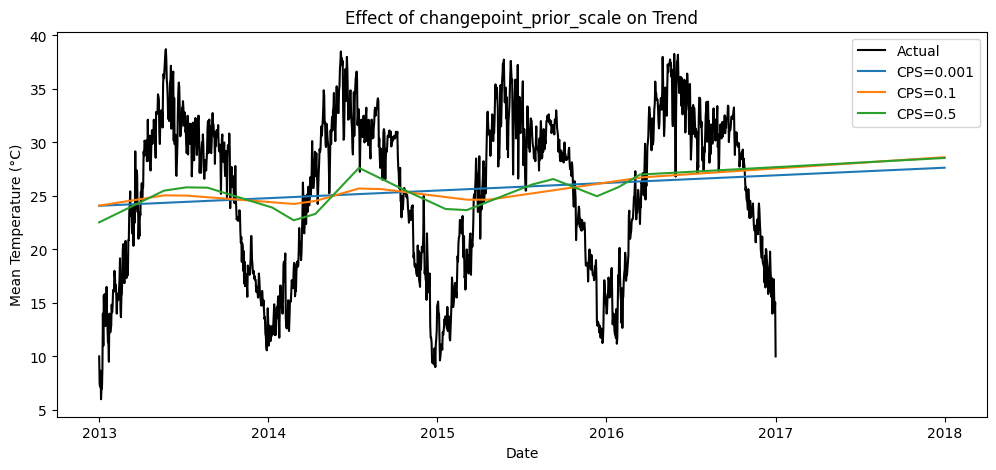

In [27]:
# TODO 6.1: Fit three Prophet models with changepoint_prior_scale = [0.001, 0.1, 0.5].
# Store trend forecasts in a dict: {scale_value: forecast_df}.
cps_results = {}

for cps in [0.001, 0.1, 0.5]:
    m = Prophet(changepoint_prior_scale=cps)
    m.fit(pro_df)
    future = m.make_future_dataframe(periods=365)
    forecast = m.predict(future)
    cps_results[cps] = forecast

# TODO 6.2: Plot all three trend lines on a single matplotlib figure (figsize=(12, 5)).
# Overlay the actual y series in black for reference.
# Label each trend line with its changepoint_prior_scale value in the legend.
fig, ax = plt.subplots( figsize=(12, 5))

ax.plot(pro_df["ds"], pro_df["y"], color="black", label="Actual")
for cps, forcast_df in cps_results.items():
	ax.plot(forcast_df["ds"], forcast_df["trend"], label=f"CPS={cps}")
ax.set_title("Effect of changepoint_prior_scale on Trend")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Temperature (°C)")
ax.legend()
plt.show()

* changing cps show me model if its underfitting or overfitting or fitting data
* the 0.001 is underfitting data its too rigid and doesnt change with trend
* 0.1 is kinda balanced it changes with trend but not too much to overfit data
* 0.5 is overfitting data, changing with trend highly

19:02:20 - cmdstanpy - INFO - Chain [1] start processing
19:02:20 - cmdstanpy - INFO - Chain [1] done processing


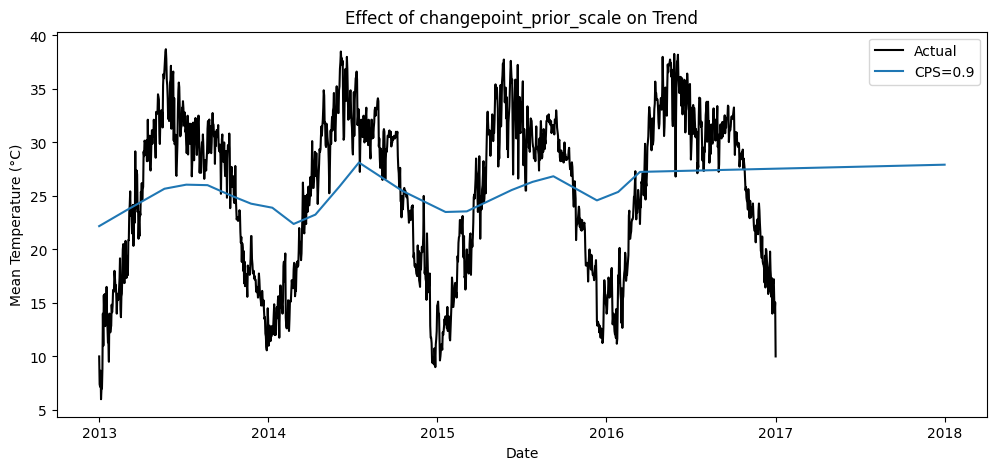

In [28]:
m = Prophet(changepoint_prior_scale=0.9)
m.fit(pro_df)
future = m.make_future_dataframe(periods=365)
forecast = m.predict(future)

# TODO 6.2: Plot all three trend lines on a single matplotlib figure (figsize=(12, 5)).
# Overlay the actual y series in black for reference.
# Label each trend line with its changepoint_prior_scale value in the legend.
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(pro_df["ds"], pro_df["y"], color="black", label="Actual")
ax.plot(forecast["ds"], forecast["trend"], label=f"CPS={0.9}")
ax.set_title("Effect of changepoint_prior_scale on Trend")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Temperature (°C)")
ax.legend()
plt.show()

### Task 7: Model Trial 3 — Custom Seasonality
Disable Prophet's default seasonalities and define explicit ones using `add_seasonality()`.

19:06:57 - cmdstanpy - INFO - Chain [1] start processing
19:06:57 - cmdstanpy - INFO - Chain [1] done processing


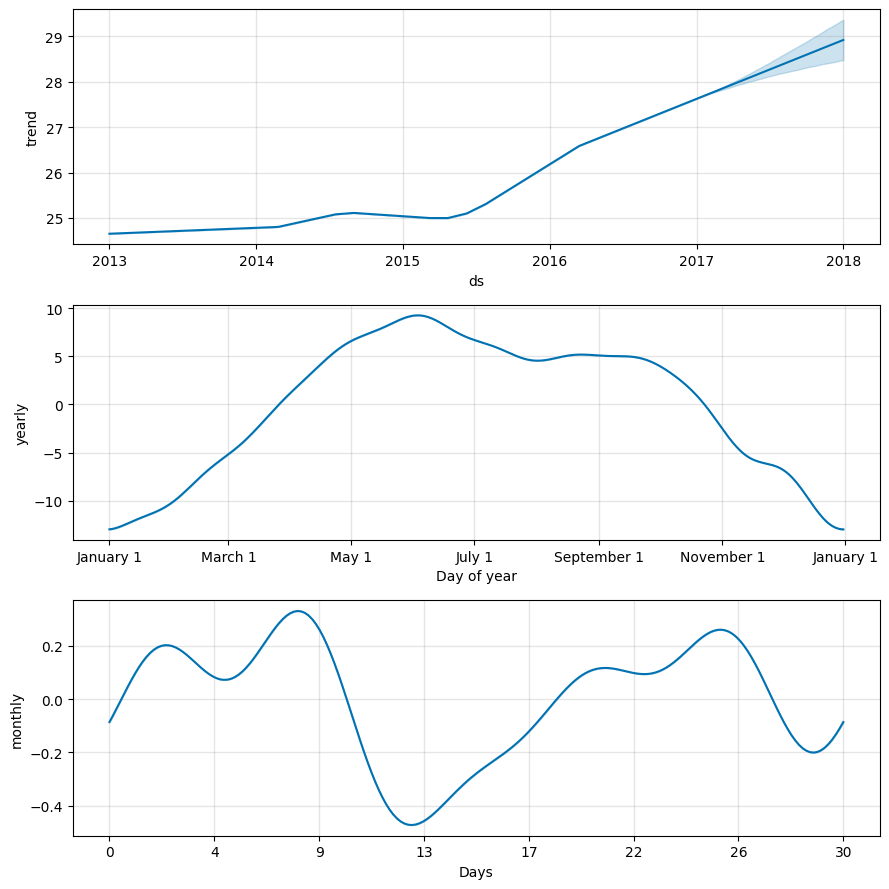

In [29]:
# TODO 7.1: Instantiate Prophet with daily_seasonality=False, weekly_seasonality=False, yearly_seasonality=False.
m2 = Prophet(daily_seasonality=False, weekly_seasonality=False, yearly_seasonality=False)
# TODO 7.2: Add a yearly seasonality using add_seasonality() with period=365.25 and fourier_order=10.
m2.add_seasonality(name='yearly', period=365.25, fourier_order=10)

# TODO 7.3: Add a monthly seasonality with period=30.5 and fourier_order=5.
m2.add_seasonality(name='monthly', period=30.5, fourier_order=5)

# TODO 7.4: Fit, forecast 365 days, and call m3.plot_components(forecast3) to inspect seasonality.
m2.fit(pro_df)
future2 = m2.make_future_dataframe(periods=365)
forecast2 = m2.predict(future2)
m2.plot_components(forecast2)
plt.tight_layout()
plt.show()

### Task 8: Model Trial 4 — Adding External Regressors
Prophet supports additional regressors that can improve forecast accuracy.

19:14:34 - cmdstanpy - INFO - Chain [1] start processing
19:14:34 - cmdstanpy - INFO - Chain [1] done processing


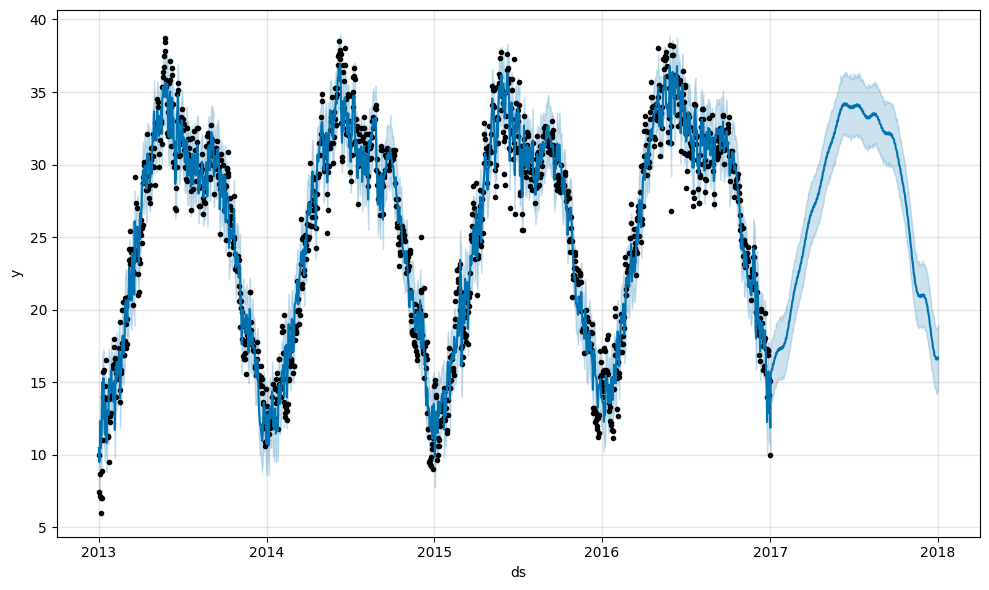

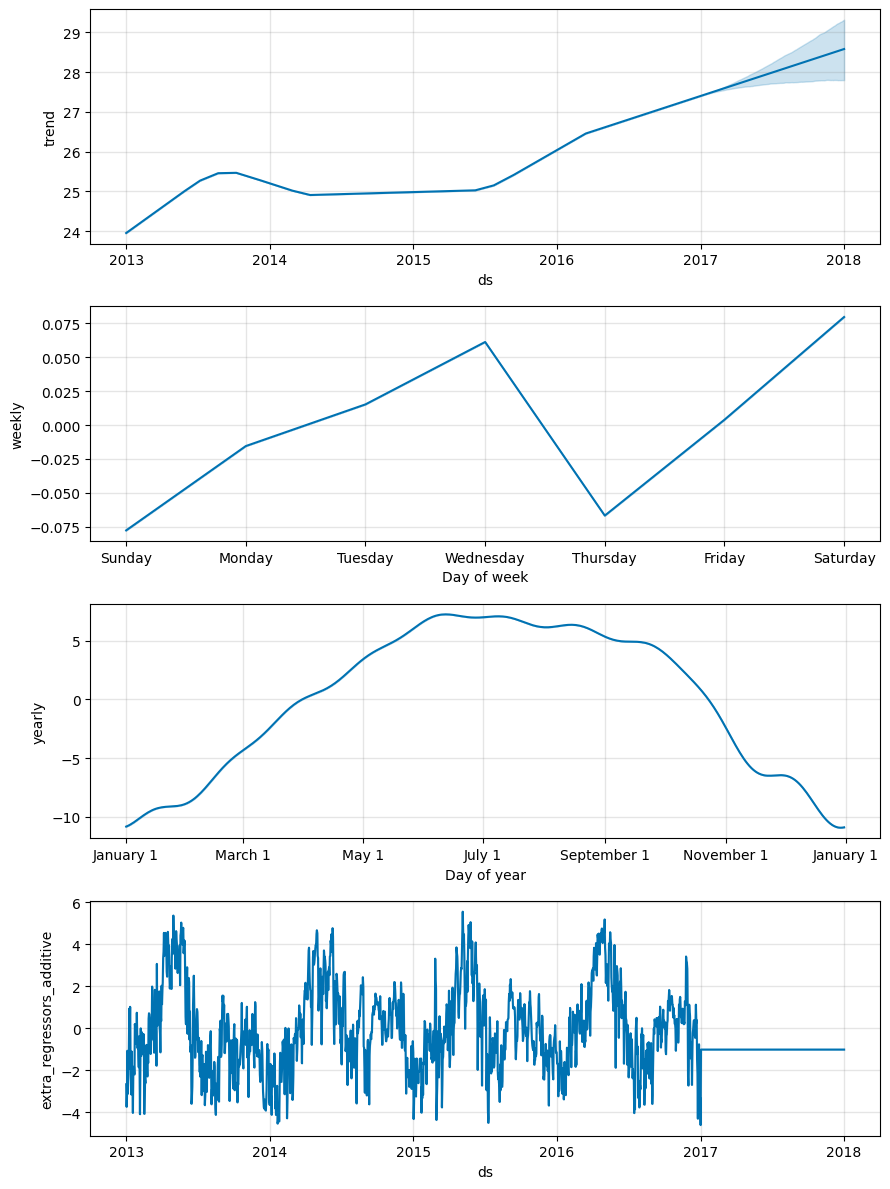

In [31]:
# TODO 8.1: Include 'humidity' and 'wind_speed' from the original dataset.
# Rebuild the prophet DataFrame with columns: ['ds', 'y', 'humidity', 'wind_speed'].
prophet_df_reg = prophet_df[["ds", "y", "humidity", "wind_speed"]].dropna()

# TODO 8.2: Instantiate Prophet and add both regressors using add_regressor().
m4 = Prophet()
m4.add_regressor("humidity")
m4.add_regressor("wind_speed")

# TODO 8.3: Fit the model. For the future dataframe, fill regressor columns with their
# rolling mean (use the last 30-day window mean as a simple proxy).
m4.fit(prophet_df_reg)
future4 = m4.make_future_dataframe(periods=365)
future4 = future4.merge(prophet_df_reg[['ds', 'humidity', 'wind_speed']], on='ds', how='left')
last_30_humidity = prophet_df_reg['humidity'].tail(30).mean()
last_30_wind = prophet_df_reg['wind_speed'].tail(30).mean()
future4['humidity'] = future4['humidity'].fillna(last_30_humidity)
future4['wind_speed'] = future4['wind_speed'].fillna(last_30_wind)

# TODO 8.4: Predict and plot using m4.plot(forecast4) and m4.plot_components(forecast4).
forecast4 = m4.predict(future4)
m4.plot(forecast4)
m4.plot_components(forecast4)
plt.tight_layout()
plt.show()

* model cant work with nan values in regressor columns. filling it with mean from last 30 days

### Task 9: Changepoint Visualization
Identify where Prophet detected the most significant trend shifts and overlay them on the series.

     changepoint     delta
1168  2016-03-14 -0.122692
888   2015-06-08  0.112639
841   2015-04-22  0.107692
420   2014-02-25  0.095501
607   2014-08-31 -0.074990


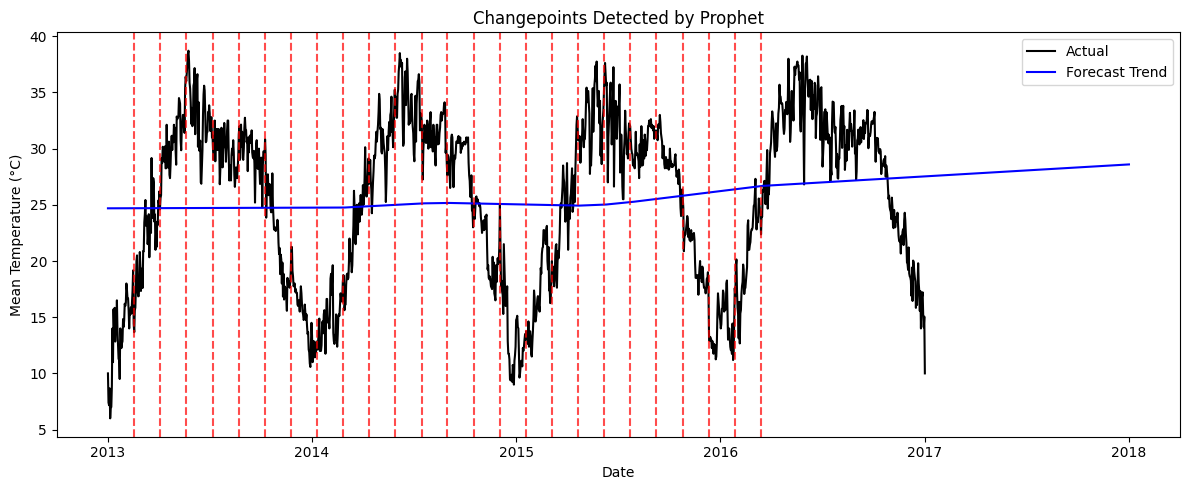

In [35]:
# TODO 9.1: Access m1.changepoints and m1.params['delta'] (trend rate changes).
# Print the top 5 changepoints sorted by abs(delta) descending.
deltas = m1.params["delta"][0]
cp_df = pd.DataFrame({
    'changepoint': m1.changepoints,
    'delta': deltas,
    'abs_delta': np.abs(deltas)
})

top_5_cp = cp_df.sort_values("abs_delta", ascending=False).head(5)
print(top_5_cp[["changepoint", "delta"]])
# TODO 9.2: Build a matplotlib figure (figsize=(12, 5)) that overlays:
# - The actual y series in black
# - The forecast trend from forecast1 in blue
# - Vertical dashed red lines at each detected changepoint
# Add a legend and title.'

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pro_df["ds"], pro_df["y"], color="black", label="Actual")
ax.plot(forecast1["ds"], forecast1["trend"], color="blue", label="Forecast Trend")
for cp in m1.changepoints:
	ax.axvline(x=cp, color="red", linestyle="--", alpha=0.7)	
ax.set_title("Changepoints Detected by Prophet")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Temperature (°C)")
ax.legend()
plt.tight_layout()
plt.show()

### Task 10: Cross-Validation
Use Prophet's built-in time-series cross-validation to evaluate generalization.

In [36]:
# TODO 10.1: Run cross_validation() on m1 with:
# - initial='730 days'
# - period='180 days'
# - horizon='365 days'
df_cv = cross_validation(
    m1,
    initial='730 days',
	period='180 days',
	horizon='365 days'
)
# TODO 10.2: Print df_cv.head() and list the unique cutoff dates.
print(df_cv.head())
print(df_cv['cutoff'].unique())

  0%|          | 0/3 [00:00<?, ?it/s]19:25:58 - cmdstanpy - INFO - Chain [1] start processing
19:25:58 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 1/3 [00:00<00:00,  3.57it/s]19:25:58 - cmdstanpy - INFO - Chain [1] start processing
19:25:58 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 2/3 [00:00<00:00,  3.70it/s]19:25:59 - cmdstanpy - INFO - Chain [1] start processing
19:25:59 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 3/3 [00:00<00:00,  3.64it/s]

          ds       yhat  yhat_lower  yhat_upper       y     cutoff
0 2015-01-08  12.381562    9.920464   14.888658  10.000 2015-01-07
1 2015-01-09  12.442425   10.109387   14.989611  10.625 2015-01-07
2 2015-01-10  12.640960   10.179656   14.947685  11.125 2015-01-07
3 2015-01-11  12.765096   10.280279   15.164020  11.000 2015-01-07
4 2015-01-12  13.272029   10.669573   15.639448  10.625 2015-01-07
<DatetimeArray>
['2015-01-07 00:00:00', '2015-07-06 00:00:00', '2016-01-02 00:00:00']
Length: 3, dtype: datetime64[ns]


### Task 11: Performance Metrics
Compute rolling performance metrics across the cross-validation horizon.

Available columns in df_perf:
['horizon', 'mse', 'rmse', 'mae', 'mape', 'mdape', 'smape', 'coverage']

First 10 rows of df_perf:
  horizon       mse      rmse       mae      mape     mdape     smape  coverage
0 37 days  5.805343  2.409428  1.872996  0.112905  0.075799  0.111481  0.718654
1 38 days  5.695894  2.386607  1.851588  0.110735  0.070641  0.109395  0.721713
2 39 days  5.557741  2.357486  1.816750  0.108372  0.070641  0.106966  0.737003
3 40 days  5.354143  2.313902  1.796032  0.106565  0.070641  0.105237  0.737003
4 41 days  4.935280  2.221549  1.747165  0.103146  0.069569  0.102065  0.752294
5 42 days  4.503331  2.122105  1.673468  0.098977  0.067834  0.098154  0.764526
6 43 days  4.507605  2.123112  1.664538  0.097509  0.065984  0.096915  0.767584
7 44 days  4.617218  2.148771  1.656387  0.096102  0.064277  0.095652  0.767584
8 45 days  4.675610  2.162316  1.652135  0.095224  0.063622  0.094814  0.767584
9 46 days  4.686022  2.164722  1.662319  0.094934  0.063622  0.094392  

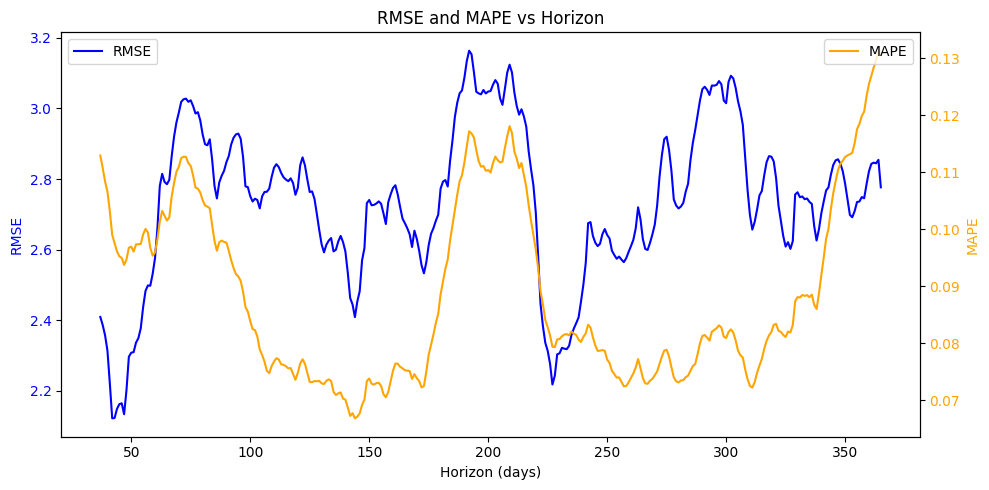

In [45]:
# TODO 11.1: Run performance_metrics(df_cv, rolling_window=0.1) and assign to df_perf.
df_perf = performance_metrics(df_cv, rolling_window=0.1)

# TODO 11.2: Print available columns and display the first 10 rows.
print("Available columns in df_perf:")
print(df_perf.columns.tolist())
print("\nFirst 10 rows of df_perf:")
print(df_perf.head(10))

# TODO 11.3: Plot RMSE and MAPE vs horizon on a single matplotlib figure with two y-axes.
# Use fig, ax1 = plt.subplots(figsize=(10, 5)) and ax2 = ax1.twinx().
# Convert horizon to days using .dt.days for the x-axis.
fig, ax1 = plt.subplots(figsize=(10, 5))
horizon_days = df_perf["horizon"].dt.days
# left axis for RMSE
ax1.plot(horizon_days, df_perf["rmse"], color="blue", label="RMSE")
ax1.set_xlabel("Horizon (days)")
ax1.set_ylabel("RMSE", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")
ax1.set_title("RMSE and MAPE vs Horizon")
ax1.legend(loc="upper left")
ax2 = ax1.twinx()

# right axis for MAPE
ax2.plot(horizon_days, df_perf["mape"], color="orange", label="MAPE")
ax2.set_ylabel("MAPE", color="orange")
ax2.tick_params(axis='y', labelcolor="orange")
ax2.legend(loc="upper right")
fig.tight_layout()
plt.show()

### Task 12: Model Comparison — RMSE Across Trials
Compare the in-sample RMSE of all model trials against a naive mean baseline.

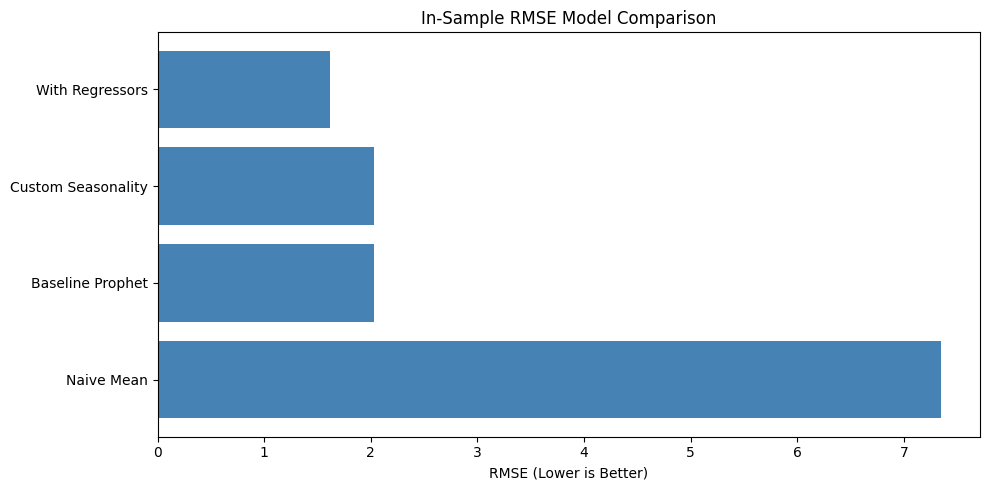

In [48]:
# TODO 12.1: For each fitted model (m1, m3, m4), compute in-sample RMSE:
# Merge forecast['ds', 'yhat'] with prophet_df on 'ds', then compute sqrt(mean((y - yhat)^2)).
def calc_rmse(forecast_df, actual_df):
    merged = pd.merge(actual_df, forecast_df[['ds', 'yhat']], on='ds', how='inner')
    rmse = np.sqrt(np.mean((merged['y'] - merged['yhat'])**2))
    return rmse

rmse_m1 = calc_rmse(forecast1, pro_df)
rmse_m2 = calc_rmse(forecast2, pro_df)
rmse_m4 = calc_rmse(forecast4, prophet_df_reg)

# TODO 12.2: Compute the naive baseline RMSE using the global mean of y as the prediction.
naive_mean = pro_df["y"].mean()
rmse_naive = np.sqrt(np.mean((pro_df["y"] - naive_mean) ** 2))
# TODO 12.3: Plot a horizontal bar chart with matplotlib comparing RMSE across:
# ['Baseline Prophet', 'Custom Seasonality', 'With Regressors', 'Naive Mean']
# Sort bars from lowest to highest RMSE.
rmse_results = {
    'Baseline Prophet': rmse_m1,
    'Custom Seasonality': rmse_m2,
    'With Regressors': rmse_m4,
    'Naive Mean': rmse_naive
}
sorted_results = dict(sorted(rmse_results.items(), key=lambda item: item[1], reverse=True))
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(list(sorted_results.keys()), list(sorted_results.values()), color='steelblue')
ax.set_xlabel('RMSE (Lower is Better)')
ax.set_title('In-Sample RMSE Model Comparison')
plt.tight_layout()
plt.show()

### Task 13: Final Forecast with Prediction Intervals
Load the test set and evaluate your best model's out-of-sample forecast with uncertainty bands.

* best model was the one that contained regressors of 2 columns humidity and windspeed

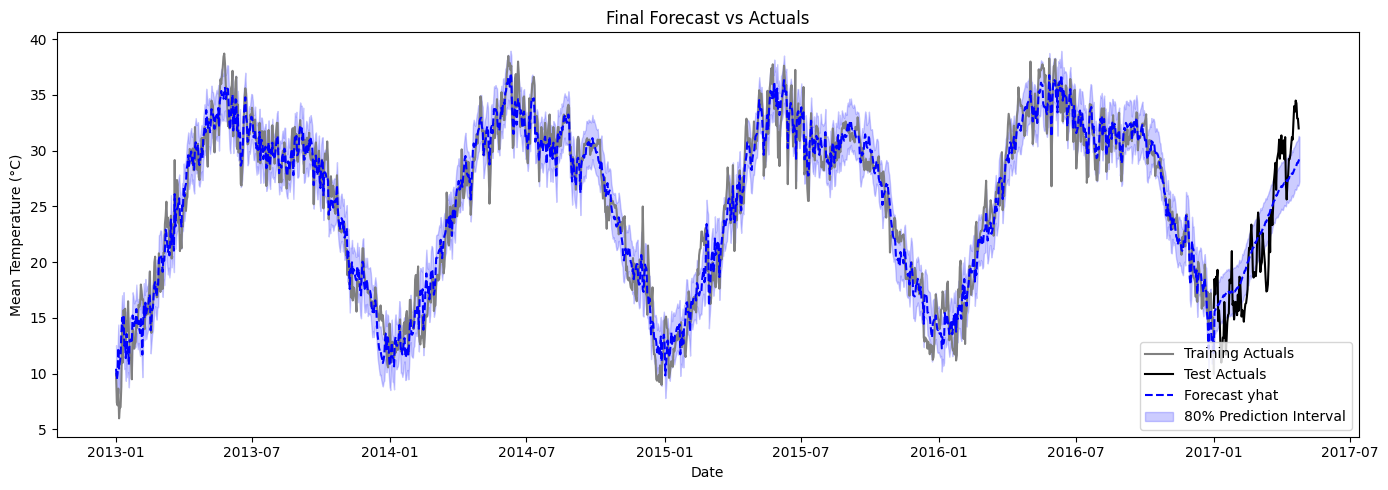

Test RMSE: 3.0522086104501476
Test MAPE: 13.319603326014903


In [49]:
# TODO 13.1: Load 'DailyDelhiClimateTest.csv'. Rename 'date' -> 'ds', 'meantemp' -> 'y'.
df_test = pd.read_csv("DailyDelhiClimateTest.csv")
df_test = df_test.rename(columns={"date": "ds", "meantemp": "y"})
df_test["ds"] = pd.to_datetime(df_test["ds"])

# TODO 13.2: Using your best model, generate a forecast that covers the test period.
# Hint: make_future_dataframe(periods=len(df_test)) starting from end of training.
forecast_final = m4.make_future_dataframe(periods=len(df_test))
forecast_final = forecast_final.merge(prophet_df_reg[['ds', 'humidity', 'wind_speed']], on='ds', how='left')
last_30_humidity = prophet_df_reg['humidity'].tail(30).mean()
last_30_wind = prophet_df_reg['wind_speed'].tail(30).mean()
forecast_final['humidity'] = forecast_final['humidity'].fillna(last_30_humidity)
forecast_final['wind_speed'] = forecast_final['wind_speed'].fillna(last_30_wind)
forecast_final = m4.predict(forecast_final)

# TODO 13.3: Build a matplotlib figure (figsize=(14, 5)) with:
# - Training actuals: grey line
# - Test actuals: black line
# - Forecast yhat: blue dashed line
# - Shaded 80% prediction interval using ax.fill_between(yhat_lower, yhat_upper, alpha=0.2)
# Add legend, title, and axis labels.
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pro_df["ds"], pro_df["y"], color="grey", label="Training Actuals")
ax.plot(df_test["ds"], df_test["y"], color="black", label="Test Actuals")
ax.plot(forecast_final["ds"], forecast_final["yhat"], color="blue", linestyle="--", label="Forecast yhat")
ax.fill_between(forecast_final["ds"], forecast_final["yhat_lower"], forecast_final["yhat_upper"], color="blue", alpha=0.2, label="80% Prediction Interval")
ax.set_title("Final Forecast vs Actuals")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Temperature (°C)")
ax.legend()
plt.tight_layout()
plt.show()
# TODO 13.4: Compute and print test RMSE and MAPE.
test_merged = pd.merge(df_test, forecast_final[['ds', 'yhat']], on='ds', how='inner')
test_rmse = np.sqrt(np.mean((test_merged['y'] - test_merged['yhat'])**2))
test_mape = np.mean(np.abs((test_merged['y'] - test_merged['yhat']) / test_merged['y'])) * 100
print(f"Test RMSE: {test_rmse}")
print(f"Test MAPE: {test_mape}")

### Task 14: Model Serialization
Save your best model to disk using Prophet's JSON serialization for reproducibility.

In [50]:
# TODO 14.1: Import model_to_json and model_from_json from prophet.serialize.
import json
from prophet.serialize import model_to_json, model_from_json
# TODO 14.2: Serialize your best model to a JSON file named 'prophet_delhi_model.json'.
with open("prophet_delhi_model.json", "w")as f:
    json.dump(model_to_json(m4), f)
# TODO 14.3: Reload the model from the file using model_from_json.
with open('prophet_delhi_model.json', 'r') as fin:
    loaded_model = model_from_json(json.load(fin))
# TODO 14.4: Run predict() on the loaded model and verify yhat matches the original
loaded_forcast = loaded_model.predict(future4)
# by printing the max absolute delta between the two forecast yhat columns.
max_delta = np.abs(loaded_forcast['yhat'] - forecast4['yhat']).max()
print(f"Max absolute delta between original and loaded model forecasts: {max_delta}")
if max_delta == 0:
    print("Success: Loaded model forecasts match the original model forecasts exactly.")

Max absolute delta between original and loaded model forecasts: 0.0
Success: Loaded model forecasts match the original model forecasts exactly.
